In [43]:
import lingam, maxcorr, sys, numpy
import importlib.metadata as meta
from maxcorr import indicator           # generic builder
# or, shorter alias for the same thing:
from maxcorr import hgr    

In [44]:
# ------------------------------------------------------------
# Checkpoint 1 – Environment & imports
# ------------------------------------------------------------
# (If you've already installed the packages in the terminal,
#  the first two lines are optional.)
# !pip install -qU maxcorr lingam

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lingam import DirectLiNGAM
from maxcorr import hgr          # builder for the HGR double-kernel estimator

# Show library versions for the record
import importlib.metadata as meta
vers = {p: meta.version(p) for p in ["numpy", "pandas",
                                     "matplotlib", "lingam", "maxcorr"]}
print(vers)


{'numpy': '1.26.4', 'pandas': '2.3.0', 'matplotlib': '3.10.3', 'lingam': '1.10.0', 'maxcorr': '0.1.2'}


In [48]:
# ------------------------------------------------------------
# Checkpoint 2  (re-write) – data generators (row-wise B)
# ------------------------------------------------------------
import numpy as np

def _random_dag(p, sparsity, rng):
    """Row = child, Col = parent, strictly lower-triangular B."""
    Wraw  = rng.uniform(0.5, 2.0, size=(p, p))
    signs = rng.choice([-1, 1], size=(p, p))
    mask  = rng.random(size=(p, p)) < sparsity
    B     = np.tril(Wraw * signs * mask, k=-1)   # child j depends on k<j
    return B

def gen_linear_ng(n=10000, p=6, sparsity=0.3, df=3, seed=0):
    rng = np.random.default_rng(seed)
    B   = _random_dag(p, sparsity, rng)
    E   = rng.standard_t(df=df, size=(n, p))      # non-Gaussian noise
    X   = np.zeros((n, p))
    for j in range(p):                            # causal order: 0‥p-1
        parents = B[j, :j]                        # coefficients B[j,k], k<j
        X[:, j] = X[:, :j] @ parents + E[:, j]
    return X, B

def gen_nonlinear_pnl(n=10000, p=6, sparsity=0.3, seed=0):
    X_lin, B = gen_linear_ng(n, p, sparsity, seed=seed)
    rng = np.random.default_rng(seed + 10)
    funcs = [np.tanh, np.sin, lambda x: x**3,
             lambda x: x + 0.5*np.cos(x), np.square, np.exp]
    X_nl = np.zeros_like(X_lin)
    for j in range(p):
        parent_signal = X_lin[:, :j] @ B[j, :j]    # same parents, row-wise
        X_nl[:, j] = funcs[j % len(funcs)](parent_signal) \
                     + 0.2 * rng.standard_normal(n)  # small extra noise
    return X_nl, B

# ---------- smoke-test ----------
X_lin, B_gt = gen_linear_ng()
X_nl, _     = gen_nonlinear_pnl()

print("Shapes →", X_lin.shape, X_nl.shape,
      "| edges:", (B_gt != 0).sum())


Shapes → (10000, 6) (10000, 6) | edges: 2


In [49]:
# --- peek at the adjacency values ------------------------------------------
print("B_gt non-zeros (row=child, col=parent):")
rows, cols = np.nonzero(B_gt)
for r, c in zip(rows, cols):
    print(f"  parent {c}  -> child {r}   weight = {B_gt[r, c]:.2f}")

# --- and the causal (topological) order according to the graph -------------
import networkx as nx
G_tmp = nx.DiGraph([(c, r) for r, c in zip(rows, cols)])
G_tmp.add_nodes_from(range(B_gt.shape[0]))   # include isolated nodes
print("Topological order:", list(nx.topological_sort(G_tmp)))


B_gt non-zeros (row=child, col=parent):
  parent 0  -> child 2   weight = 1.79
  parent 4  -> child 5   weight = -1.29
Topological order: [0, 4, 1, 3, 2, 5]


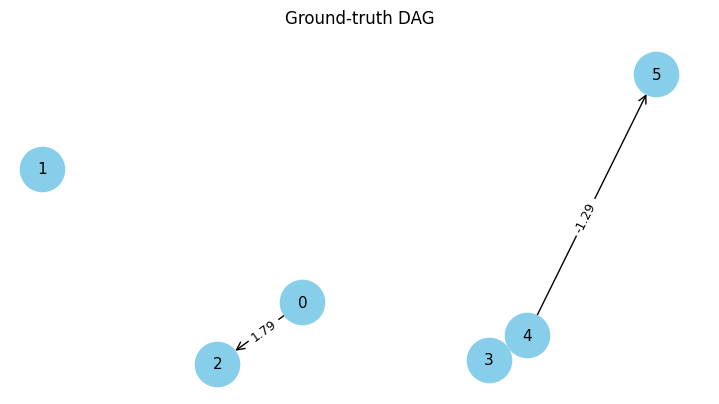

Topological order (by construction): [0, 1, 2, 3, 4, 5]


In [50]:
# ------------------------------------------------------------
# TRUE DAG VISUALISATION  – all nodes, all parent/child links
# ------------------------------------------------------------
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def plot_true_dag(B, labels=None, show_weights=True, title="Ground-truth DAG"):
    """
    Draw every edge in the DAG represented by B (rows = child, cols = parent).
    If Graphviz is available, uses a crisp hierarchical layout; otherwise
    falls back to NetworkX's spring layout so edges don't overlap.
    
    Parameters
    ----------
    B : ndarray, shape (p, p)
        Row-wise weight matrix: B[j, k] ≠ 0 means k → j, with k < j.
    labels : list of hashables, optional
        Node labels; default = 0, 1, …, p-1.
    show_weights : bool
        If True, annotate each edge with its weight.
    """
    # ---------- build the DiGraph ----------
    p = B.shape[0]
    labels = list(range(p)) if labels is None else labels
    G = nx.DiGraph()
    G.add_nodes_from(labels)

    for j in range(p):
        for k in range(j):                       # parents only at lower index
            w = B[j, k]
            if abs(w) > 1e-8:
                G.add_edge(labels[k], labels[j], weight=w)

    # ---------- choose a layout ----------
    try:
        # Graphviz hierarchical layout (left-to-right)
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot")   # needs pygraphviz or pydot
    except (ImportError, nx.NetworkXException):
        # Fallback: spring layout with a fixed seed → stable picture
        pos = nx.spring_layout(G, seed=1)

    # ---------- draw ----------
    plt.figure(figsize=(7, 3.5))
    nx.draw(
        G, pos,
        with_labels=True,
        arrows=True, arrowstyle="->", arrowsize=14,
        node_size=1000, node_color="skyblue",
        linewidths=1.2, font_size=11
    )

    if show_weights:
        edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                     font_size=9, label_pos=0.45)

    plt.title(title, pad=15)
    plt.axis("off")
    plt.show()

# -------- call it on the current ground-truth matrix --------
plot_true_dag(B_gt)

print("Topological order (by construction):", list(range(B_gt.shape[0])))


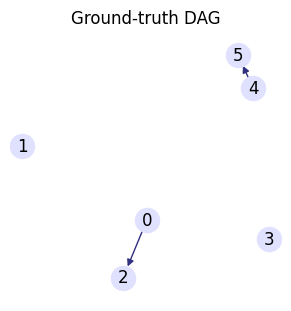

In [9]:
def show_dag(adj, title=None, ax=None, lingam_style=True, thresh=0.0):
    """
    Visualise a DAG from an adjacency / weight matrix.

    Parameters
    ----------
    adj : (p, p) ndarray
        Weight matrix. If lingam_style=True, entry (i, j) is weight of
        edge j → i (LiNGAM convention).  Otherwise (i, j) is i → j.
    title : str
        Figure title.
    ax : matplotlib Axes or None
        If None, creates a new 3.5×3.5" axes.
    lingam_style : bool
        Set False if your matrix already follows the standard graph
        convention (row = source, col = target).
    thresh : float
        Only draw edges whose absolute weight exceeds this value.
    """
    import networkx as nx
    import matplotlib.pyplot as plt
    import numpy as np

    A = adj.copy()
    if lingam_style:
        A = A.T                     # flip to (source,row) format

    # keep only edges above threshold and convert to 0/1
    A = (np.abs(A) > thresh).astype(int)

    G = nx.DiGraph(A)
    pos = nx.spring_layout(G, seed=1)

    if ax is None:
        _, ax = plt.subplots(figsize=(3.5, 3.5))

    nx.draw_networkx(G, pos,
                     arrows=True,
                     with_labels=True,
                     ax=ax,
                     node_color="#e0e0ff",
                     edge_color="#303080")

    ax.set_axis_off()
    if title:
        ax.set_title(title)

show_dag(B_gt, title="Ground-truth DAG", lingam_style=True)

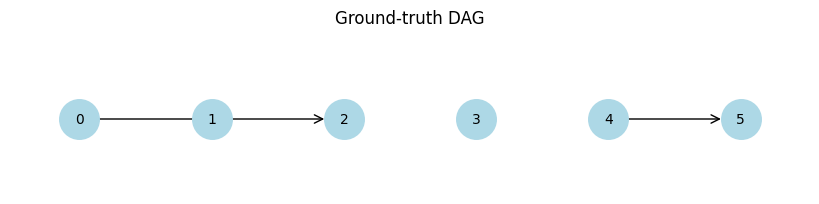

Causal order (topological): [0, 1, 2, 3, 4, 5]


In [10]:
# ------------------------------------------------------------
# (Optional) Visualise the ground-truth DAG
# ------------------------------------------------------------
import networkx as nx
import matplotlib.pyplot as plt

def plot_dag(B, node_labels=None):
    """
    Draws a DAG given its adjacency matrix B (rows = child, cols = parent).
    """
    G = nx.DiGraph()
    p = B.shape[0]
    if node_labels is None:
        node_labels = list(range(p))
    G.add_nodes_from(node_labels)

    # add directed edges where |B[j,k]| > 0
    for j in range(p):
        for k in range(j):          # only k<j can be parents
            if abs(B[j, k]) > 1e-8:
                G.add_edge(node_labels[k], node_labels[j])

    # layout: parents on the left, children to the right (simple x-coordinate)
    pos = {node_labels[i]: (i, 0) for i in range(p)}

    plt.figure(figsize=(8, 1.5))
    nx.draw(G, pos,
            with_labels=True, arrows=True,
            node_size=800, node_color="lightblue",
            arrowstyle="->", arrowsize=15,
            linewidths=1.2, font_size=10)
    plt.title("Ground-truth DAG", pad=15)
    plt.axis("off")
    plt.show()

# --- call the helper on our current B_gt ---
plot_dag(B_gt)

print("Causal order (topological):", list(range(B_gt.shape[0])))


In [12]:
def shd(A, B, tol=1e-2):
    return int(np.sum((np.abs(A) > tol) != (np.abs(B) > tol)))

In [13]:

# ---------- Fit on linear data ----------
model_lin = DirectLiNGAM(random_state=0)
model_lin.fit(X_lin)

B_lin_est = model_lin.adjacency_matrix_
order_lin = model_lin.causal_order_

# ---------- Fit on non-linear data ----------
model_nl = DirectLiNGAM(random_state=0)
model_nl.fit(X_nl)

B_nl_est = model_nl.adjacency_matrix_
order_nl = model_nl.causal_order_

# ---------- Evaluate ----------
print("=== Linear data ===")
print("Recovered causal order :", order_lin)
print("SHD vs ground truth    :", shd(B_lin_est, B_gt))

print("\n=== Non-linear data ===")
print("Recovered causal order :", order_nl)
print("SHD vs ground truth    :", shd(B_nl_est, B_gt))


=== Linear data ===
Recovered causal order : [4, 1, 5, 3, 0, 2]
SHD vs ground truth    : 0

=== Non-linear data ===
Recovered causal order : [5, 4, 2, 3, 0, 1]
SHD vs ground truth    : 2


In [30]:
import hgrlingam as hl
from maxcorr import hgr as _hgr_builder
e = _hgr_builder(algorithm="dk", backend="numpy")
print("Estimator type:", type(e), "has:", [a for a in dir(e) if not a.startswith('_')][:10])


Estimator type: <class 'maxcorr.indicators.kernel.DoubleKernelIndicator'> has: ['Result', 'algorithm', 'alpha', 'backend', 'beta', 'compute', 'delta_independent', 'eps', 'f', 'g']


In [42]:
import importlib, hgrlingam as hl
importlib.reload(hl)

# try explicit bandwidths (
mdl = hl.HGRDirectLiNGAM(kernel_sizes=(1, 1), random_state=0)
mdl.fit(X_lin)

print("Linear SHD:", hl.shd(mdl.adjacency_matrix_, B_gt))
print("HGR calls :", hl.HGRDirectLiNGAM._hgr_calls)


Linear SHD: 2
HGR calls : 70


In [32]:
from lingam import DirectLiNGAM            # library default (PW-Ling)
pw_lin = DirectLiNGAM(random_state=0).fit(X_lin)

print("Baseline SHD:", hl.shd(pw_lin.adjacency_matrix_, B_gt))
print("HGR      SHD:", hl.shd(model.adjacency_matrix_, B_gt))


Baseline SHD: 0
HGR      SHD: 2
